Problem 2

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


df = pd.read_csv("ABP-B.csv",skiprows=2)
df['Time (sec)'] = df['Time (sec)'] - df['Time (sec)'].iloc[0] # normalize time
df['RPM'] = df['RPM'] - df['RPM'].iloc[0] # normalize RPM
df['Fuel Flow  (L/hr)'] = df['Fuel Flow  (L/hr)'] - df['Fuel Flow  (L/hr)'].iloc[0] # normalize Fuel Flow
df['Thrust (N)'] = df['Thrust (N)'] - df['Thrust (N)'].iloc[0] # normalize Thrust
df


,Time (sec),T1 (C),T2 (C),T3 (C),T4 (C),P1 (kPa),P2 (kPa),P3 (kPa),P4 (kPa),Fuel Flow (L/hr),RPM,Thrust (N)
0,0.000,70.926,97.975,205.623,169.028,0.012,33.502,34.621,2.960,0.000,0.000,0.000
1,0.200,70.941,98.125,206.044,169.371,0.012,33.495,34.633,2.960,0.000,-1.285,0.548
2,0.400,70.937,98.086,205.144,169.189,0.012,33.502,34.626,2.960,0.000,-0.816,0.494
3,0.600,71.000,98.096,205.858,169.224,0.012,33.500,34.631,2.960,0.000,0.227,0.658
4,0.800,70.983,98.055,206.293,169.027,0.012,33.492,34.622,2.959,0.000,0.469,0.472
...,...,...,...,...,...,...,...,...,...,...,...,...
1382,276.609,50.919,123.081,206.433,251.945,0.012,33.604,34.743,2.967,0.001,2349.847,0.356
1383,276.809,50.952,123.106,206.443,252.709,0.012,33.601,34.734,2.966,0.000,2344.301,1.327
1384,277.009,51.000,123.043,206.259,251.985,0.012,33.599,34.736,2.966,0.000,2344.689,1.217
1385,277.209,51.094,122.984,206.686,251.696,0.012,33.591,34.724,2.964,0.000,2306.509,1.261


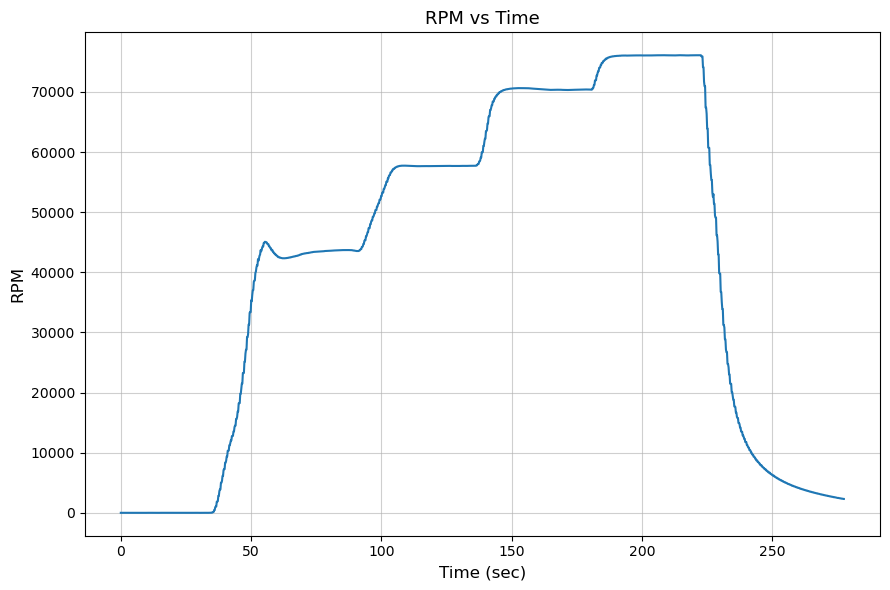

In [2]:
plt.figure(figsize=(9, 6))
plt.plot(df['Time (sec)'], df['RPM'])
plt.xlabel("Time (sec)", fontsize=12)
plt.ylabel("RPM", fontsize=12)
plt.title(
    "RPM vs Time",
    fontsize=13,
)
plt.grid(True, alpha=0.6)
plt.tight_layout()

plt.show()

In [6]:
WINDOW = 20  
STD_THRESHOLD = 50.0  

df["rpm_std"] = (
    df["RPM"].rolling(window=WINDOW, center=True).std() #sliding-window func to get std over 20 points (arbitrary number)
)


df["is_constant"] = (df["rpm_std"] < STD_THRESHOLD) #if below std threshold, bool value stored


constant_df = df[df["is_constant"]]
block_ids = (df["is_constant"] != df["is_constant"].shift()).cumsum() #isolates the values into different 'plateaus'

plateaus = (
    df[df["is_constant"]]
    .groupby(block_ids)
    .agg(
        start_time=("Time (sec)", "min"),
        end_time=("Time (sec)", "max"),
        duration=("Time (sec)", lambda t: t.max() - t.min()),
        average_rpm=("RPM", "mean"),
        average_T1 = ("T1 (C)", "mean"),
        average_T2 = ("T2 (C)", "mean"),
        average_T3 = ("T3 (C)", "mean"),
        average_T4 = ("T4 (C)", "mean"),
        average_P1 = ("P1 (kPa)", "mean"),
        average_P2 = ("P2 (kPa)", "mean"),
        average_P3 = ("P3 (kPa)", "mean"),
        average_P4 = ("P4 (kPa)", "mean"),
        average_fuel_flow = ("Fuel Flow  (L/hr)", "mean"),
        average_thrust = ("Thrust (N)", "mean")
    )

) #summary stats, used to get the average values needed

plateaus = plateaus[plateaus["duration"] >= 5.0].reset_index(drop=True) #trying to just isolate the flat section after the dip in RPM 1

print(plateaus)

   start_time  end_time  duration   average_rpm  average_T1  average_T2  \
0       2.001    33.820    31.819     -1.281588   72.602031   97.642556   
1      74.847    88.458    13.611  43601.156377   38.190739  100.800348   
2     108.072   134.887    26.815  57688.814933   35.178267  125.394733   
3     150.500   179.127    28.627  70443.194910   34.141729  164.547243   
4     190.332   220.964    30.632  76072.394409   34.005461  194.309214   

   average_T3  average_T4  average_P1  average_P2  average_P3  average_P4  \
0  205.993825  163.836806    0.012000   33.503300   34.629712    2.959406   
1  582.048841  324.591391   -0.019319   79.446928   79.996116    8.461986   
2  674.533496  331.896615   -0.025844  124.060889  123.724274   13.582415   
3  714.810257  347.736229   -0.016583  188.102972  187.153986   20.326076   
4  788.762403  355.904156   -0.014610  223.616909  222.304961   24.598026   

   average_fuel_flow  average_thrust  
0           0.000019       -0.135987  
1       

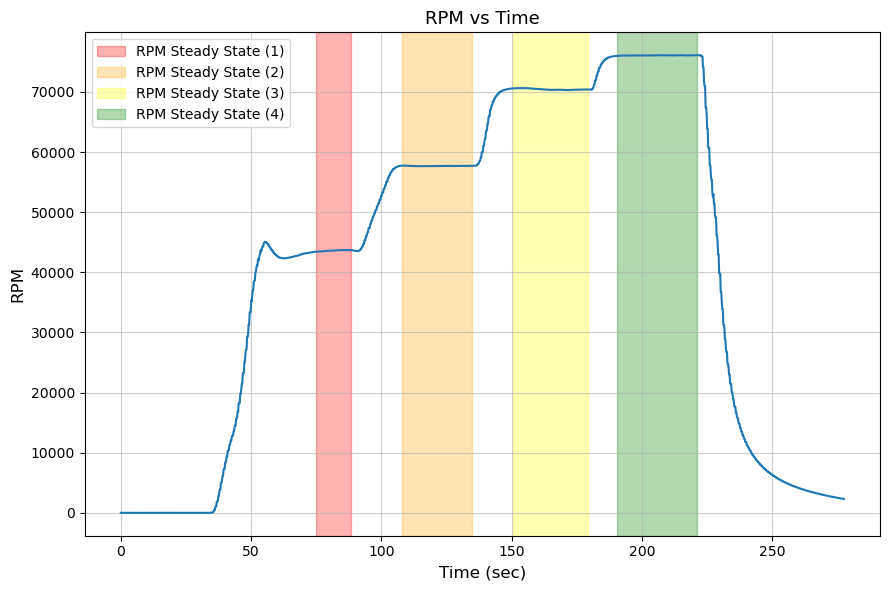

In [7]:
plt.figure(figsize=(9, 6))
plt.plot(df['Time (sec)'], df['RPM'])
plt.xlabel("Time (sec)", fontsize=12)
plt.ylabel("RPM", fontsize=12)
plt.title(
    "RPM vs Time",
    fontsize=13,
)
plt.grid(True, alpha=0.6)
plt.tight_layout()
plt.axvspan(74.847,    88.458, color='red', alpha=0.3, label = "RPM Steady State (1)")
plt.axvspan(108.072,   134.88, color='orange', alpha=0.3, label = "RPM Steady State (2)")
plt.axvspan(150.500,  179.127, color='yellow', alpha=0.3, label = "RPM Steady State (3)")
plt.axvspan(190.332,   220.964, color='green', alpha=0.3, label = "RPM Steady State (4)")
plt.legend(loc = "best")
plt.show()

Compressor Efficiency Calculation

In [8]:
#calculating the T2s to then use the tables
R = 287
cp = 1005
p_amb = 99.3
plateaus["T2s"] = (plateaus["average_T1"] + 273.15) * (
    (plateaus["average_P2"] + p_amb)  / (p_amb -plateaus["average_P1"])
) ** (R/cp)
plateaus["T2s"]

0    375.695470
1    368.226761
2    388.614489
3    416.230307
4    430.123677
Name: T2s, dtype: float64

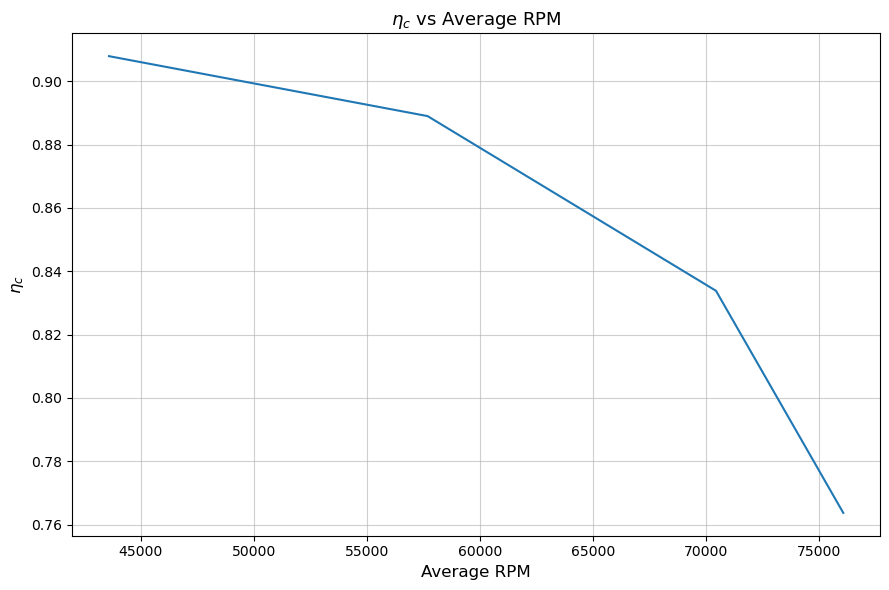

In [9]:
h1a= 311.7
h1b = 308.6
h1c = 307.5
h1d = 307.4
h2a = 374.7
h2b = 399.6
h2c = 439.3
h2d = 469.9
h2sa = 368.9
h2sb = 389.5
h2sc = 417.4
h2sd = 431.5 
#some values calculated by hand and then put in the code
letters = ['a','b','c','d']
eta_c = np.zeros(4)
for i in range(4):
    var_name1 = "h2s" +  letters[i]
    var_name2 = "h1" +  letters[i]
    var_name3 = "h2" +  letters[i]
    eta_c[i] = (globals()[var_name1]-globals()[var_name2])/(globals()[var_name3]-globals()[var_name2])
plt.figure(figsize=(9, 6))
plt.plot(plateaus.iloc[1:5]["average_rpm"],eta_c)
plt.xlabel("Average RPM", fontsize=12)
plt.ylabel(r"$\eta_c$", fontsize=12)
plt.title(
    r"$\eta_c$ vs Average RPM",
    fontsize=13,
)
plt.grid(True, alpha=0.6)
plt.tight_layout()



plt.show()




Thermal Efficiency

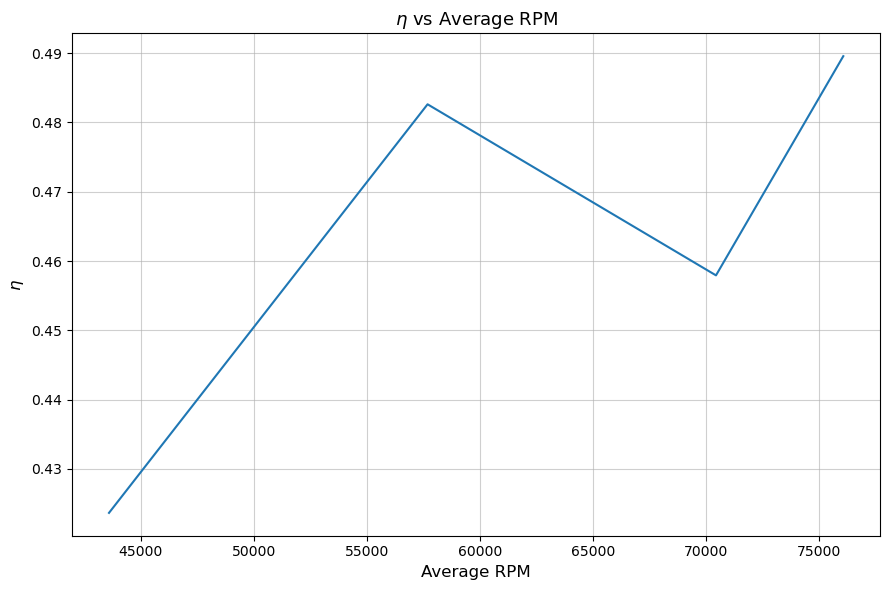

In [10]:
h3a = 882.9
h4a = 604.6
h3b = 986.6  
h4b = 612.3
h3c = 1032.4 
h4c = 629.0
h3d = 1117.0 
h4d = 637.7
#some values calculated by hand and then put in the code
eta = np.zeros(4)
for i in range(4):
    var_name1 = "h3" +  letters[i]
    var_name2 = "h1" +  letters[i]
    var_name3 = "h2" +  letters[i]
    var_name4 = "h4" +  letters[i]
    eta[i] = ((globals()[var_name1]-globals()[var_name4])-(globals()[var_name3]-globals()[var_name2]))/(globals()[var_name1]-globals()[var_name3])

plt.figure(figsize=(9, 6))
plt.plot(plateaus.iloc[1:5]["average_rpm"],eta)
plt.xlabel("Average RPM", fontsize=12)
plt.ylabel(r"$\eta$", fontsize=12)
plt.title(
    r"$\eta$ vs Average RPM",
    fontsize=13,
)
plt.grid(True, alpha=0.6)
plt.tight_layout()
plt.show()